# Semana 1 Clase 1-2

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

## Ejemplo 1

El **modelo de crecimiento geométrico** describe una cantidad que cambia en proporción a su valor actual en cada periodo de tiempo.

$$P_t = P_0(1 + r)^t$$

Donde:

$P_t =$ cantidad en el tiempo $t$,  
$P_0 =$ cantidad inicial,  
$r =$ tasa de crecimiento por periodo.

**Ejemplo:** Una colonia tiene actualmente 5000 habitantes. Cada año la población aumenta aproximadamente 3%. Queremos estimar cuántos habitantes habrá en 10 años.

In [18]:
list(range(11))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [22]:
P0 = 5000
r = 0.03
años = 10

poblacion = []

for t in range(años + 1):
    P = P0 * (1 + r)**t
    poblacion.append(P)

poblacion

[5000.0,
 5150.0,
 5304.5,
 5463.635,
 5627.54405,
 5796.3703715,
 5970.261482645001,
 6149.369327124351,
 6333.8504069380815,
 6523.865919146225,
 6719.581896720611]

In [25]:
df = pd.DataFrame({
    "Año": range(años + 1),
    "Población estimada": poblacion
})

df

,Año,Población estimada
0,0,5000.000000
1,1,5150.000000
2,2,5304.500000
3,3,5463.635000
4,4,5627.544050
5,5,5796.370372
6,6,5970.261483
7,7,6149.369327
8,8,6333.850407
9,9,6523.865919


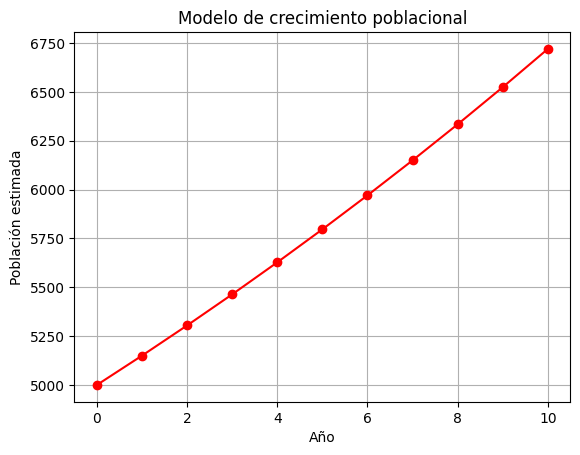

In [27]:
plt.plot(df["Año"], df["Población estimada"], marker="o", color='red')
plt.xlabel("Año")
plt.ylabel("Población estimada")
plt.title("Modelo de crecimiento poblacional")
plt.grid()
plt.show()

### ¿Qué tan bueno es el modelo?

- ¿Es razonable suponer que la población siempre crece al 3%?
- ¿Qué pasa si cambia la tasa de crecimiento?
- ¿Qué factores no estamos considerando?
- ¿Qué datos reales necesitaríamos?
- ¿Este modelo sirve para predecir a 1 año? ¿Y a 50 años?

Un modelo no es “la realidad”, sino una aproximación con supuestos.

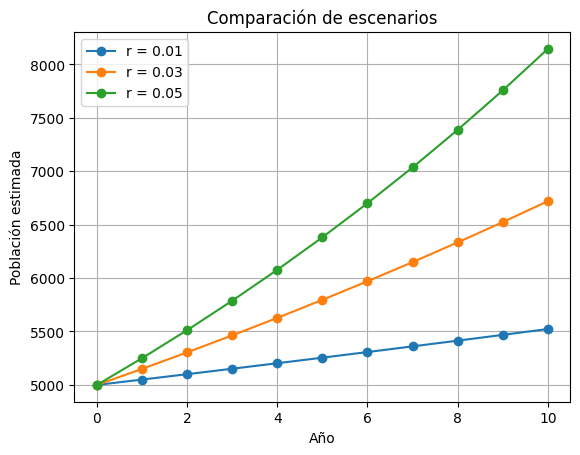

In [12]:
tasas = [0.01, 0.03, 0.05]

for r in tasas:
    poblacion = []
    for t in range(años + 1):
        P = P0 * (1 + r)**t
        poblacion.append(P)
    plt.plot(range(años + 1), poblacion, marker="o", label=f"r = {r}")

plt.xlabel("Año")
plt.ylabel("Población estimada")
plt.title("Comparación de escenarios")
plt.legend()
plt.grid()
plt.show()

## Ejemplo 2

Supongamos que tenemos una taza de café caliente con temperatura inicial de 90$^o C$. La taza se deja sobre una mesa en una habitación cuya temperatura ambiente es de 25$^o C$.

Queremos modelar cómo cambia la temperatura del café con el paso del tiempo. La pregunta principal es *¿Cómo evoluciona la temperatura del café durante los primeros minutos?.*

### Modelo matemático

Usamos una versión discreta de la ley de enfriamiento de Newton:

$$T_{t+1} = T_t - k(T_t - T_a)$$

donde:

$T_t =$ temperatura del café en el minuto $t$,  
$T_a =$ temperatura ambiente,  
$k =$ constante de enfriamiento (representa la fracción de la diferencia con el ambiente que se pierde en cada minuto).

La expresión $T_t - T_a$ representa la diferencia entre la temperatura del café y la temperatura ambiente.

Si esta diferencia es grande, el enfriamiento es más rápido.  
Si esta diferencia es pequeña, el enfriamiento es más lento.

In [13]:
# Parámetros del modelo
T0 = 90          
Ta = 25          
k = 0.08         
tiempo_total = 60   


tiempos = np.arange(0, tiempo_total + 1)
temperaturas = []

# Condición inicial
T = T0

# Simulación
for t in tiempos:
    temperaturas.append(T)
    T = T - k * (T - Ta)


df = pd.DataFrame({
    "Tiempo (min)": tiempos,
    "Temperatura (°C)": temperaturas
})

df

,Tiempo (min),Temperatura (°C)
0,0,90.000000
1,1,84.800000
2,2,80.016000
3,3,75.614720
4,4,71.565542
...,...,...
56,56,25.609581
57,57,25.560815
58,58,25.515950
59,59,25.474674


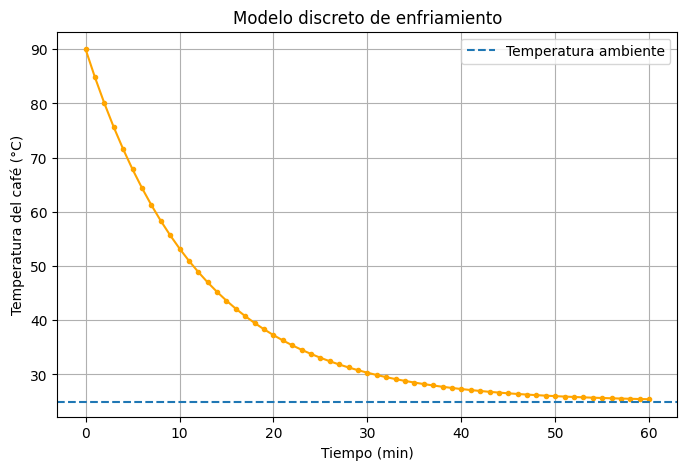

In [17]:
plt.figure(figsize=(8, 5),dpi=100)

plt.plot(df["Tiempo (min)"], df["Temperatura (°C)"], marker="o", 
         markersize=3, color='orange')

plt.axhline(y=Ta, linestyle="--", label="Temperatura ambiente")

plt.xlabel("Tiempo (min)")
plt.ylabel("Temperatura del café (°C)")
plt.title("Modelo discreto de enfriamiento")
plt.legend()
plt.grid()

plt.show()

### Interpretación de resultados

Al inicio, el café tiene una temperatura de $T_0 = 90^\circ C.$ Como la temperatura ambiente es de $T_a = 25^\circ C,$ la diferencia inicial es grande $T_0 - T_a = 90^\circ C - 25^\circ C = 65^\circ C.$

Por eso, durante los primeros minutos, el café se enfría rápidamente. Conforme pasa el tiempo, la temperatura del café se acerca a la temperatura ambiente. Sin embargo, el café no llega exactamente a 25°C en un tiempo finito dentro del modelo, sino que se aproxima gradualmente.

En términos prácticos, el modelo muestra que el enfriamiento no ocurre a una velocidad constante. Al principio la pérdida de temperatura es mayor, y después el proceso se vuelve más lento.

### ¿Qué pasa si aumentamos el valor de k?

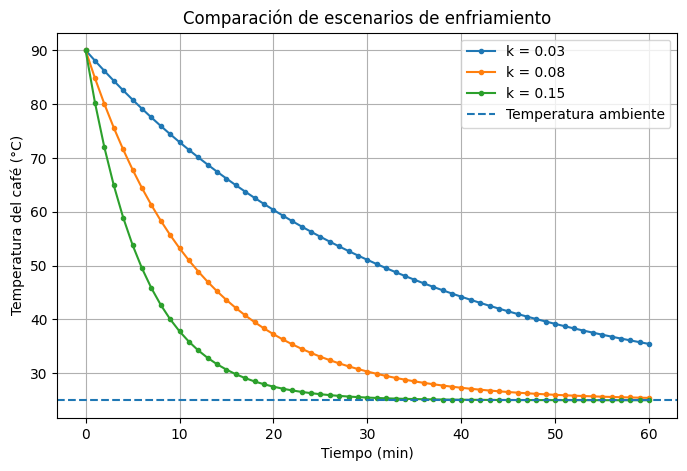

In [18]:
ks = [0.03, 0.08, 0.15]

plt.figure(figsize=(8, 5))

for k in ks:
    T = T0
    temperaturas = []

    for t in tiempos:
        temperaturas.append(T)
        T = T - k * (T - Ta)

    plt.plot(tiempos, temperaturas, marker="o", markersize=3, 
             label=f"k = {k}")

plt.axhline(y=Ta, linestyle="--", label="Temperatura ambiente")

plt.xlabel("Tiempo (min)")
plt.ylabel("Temperatura del café (°C)")
plt.title("Comparación de escenarios de enfriamiento")
plt.legend()
plt.grid()

plt.show()

### Conclusión

Este modelo permite representar de forma sencilla el proceso de enfriamiento de un objeto caliente. A partir de una ecuación simple, podemos simular el fenómeno, visualizar su comportamiento e interpretar cómo influyen los parámetros.

El ciclo completo de modelación es:

$$
\text{problema real}
\longrightarrow
\text{variables y parámetros}
\longrightarrow
\text{supuestos}
\longrightarrow
\text{modelo matemático}
\longrightarrow
\text{simulación}
\longrightarrow
\text{interpretación}.
$$


# Modelos deterministas y simulación computacional

## 1. ¿Qué es un modelo determinista?

Un **modelo determinista** es aquel en el que, dadas las condiciones iniciales y los valores de los parámetros, el resultado queda completamente determinado.

Es decir, si se repite la simulación con los mismos datos iniciales, se obtiene exactamente la misma trayectoria.

Por ejemplo, si conocemos:

$$P_0 = 1000,$$

y la regla de evolución:

$$P_{t+1} = P_t + rP_t,$$

entonces el valor de $P_t$ queda determinado para cada tiempo $t$.

### Ejemplos de modelos deterministas

Los modelos deterministas suelen dividirse en dos categorías según cómo tratan el tiempo: discreto (mediante ecuaciones en diferencias) o continuo (mediante ecuaciones diferenciales).

#### Modelos de Tiempo Discreto
El estado del sistema se actualiza en intervalos de tiempo finitos o "pasos" (por ejemplo, días, meses, años).

* **Modelo de crecimiento geométrico:**
    $$P_{t+1} = P_t(1 + r)$$
    > Modela una población que crece en proporción a su tamaño actual en periodos definidos. El parámetro $r$ es la tasa de crecimiento fraccional por periodo.

* **Modelo discreto de enfriamiento (Ley de Newton):**
    $$T_{t+1} = T_t - k(T_t - T_a)$$
    > Modela la pérdida de temperatura paso a paso. El enfriamiento es proporcional a la diferencia entre la temperatura actual $T_t$ y la del ambiente $T_a$, regulado por la constante térmica $k$.

#### Modelos de Tiempo Continuo
El estado del sistema cambia de forma ininterrumpida. Se analiza la tasa de cambio instantánea.

* **Modelo continuo de crecimiento exponencial:**
    $$\frac{dP}{dt} = rP$$
    > El equivalente continuo del crecimiento geométrico. Asume recursos ilimitados, indicando que la velocidad a la que crece la población es directamente proporcional a su tamaño actual $P$.



* **Modelo logístico de crecimiento poblacional:**
    $$\frac{dP}{dt} = rP\left(1 - \frac{P}{K}\right)$$
    > Modela un crecimiento realista al introducir el parámetro $K$ (capacidad de carga del entorno). Cuando la población $P$ es pequeña, crece casi exponencialmente; pero conforme $P$ se aproxima al límite $K$, el término $\left(1 - \frac{P}{K}\right)$ tiende a cero, deteniendo el crecimiento.

### 2. Modelo de crecimiento logístico

El modelo de crecimiento exponencial supone que una población puede crecer indefinidamente. Sin embargo, en muchos fenómenos reales esto no es razonable, porque existen limitaciones como alimento, espacio, recursos, competencia o restricciones ambientales. Para incorporar esta limitación se usa el **modelo logístico**.

**Planteamiento del problema**

Supongamos que una población inicial de bacterias, animales, personas o usuarios de una plataforma comienza con $P_0 = 100,$ y crece en un ambiente que solo puede sostener hasta aproximadamente $K = 1000$ individuos.

Queremos estudiar cómo cambia la población con el paso del tiempo.

### 3. Variables, parámetros y supuestos

**Variable principal:** $P(t) = \text{población en el tiempo } t.$

**Condición inicial:** $P(0) = P_0.$

**Parámetros:** $r = \text{tasa de crecimiento}$ y $K = \text{capacidad de carga del ambiente}.$

La capacidad de carga $K$ representa el tamaño máximo aproximado que el ambiente puede sostener.

**Supuestos del modelo**

1. La población cambia de forma continua en el tiempo.
2. La tasa de crecimiento depende del tamaño actual de la población.
3. Cuando la población es pequeña, crece casi exponencialmente.
4. Cuando la población se acerca a $K$, el crecimiento se hace más lento.
5. No se consideran eventos aleatorios, migración, cambios bruscos del ambiente ni intervención externa.

### 4. Modelo matemático

El modelo logístico está dado por:

$$\frac{dP}{dt} = rP \left(1 - \frac{P}{K}\right).$$

La expresión $rP$ representa el crecimiento natural de la población.

El término $1 - \frac{P}{K}$ reduce el crecimiento cuando la población se acerca a la capacidad de carga.

### Interpretación del modelo

Si $P$ es muy pequeña comparada con $K$, entonces:

$$\frac{P}{K} \approx 0,$$

por lo tanto:

$$1 - \frac{P}{K} \approx 1.$$

En ese caso, el modelo se parece al crecimiento exponencial:

$$\frac{dP}{dt} \approx rP.$$

Pero si $P$ se acerca a $K$, entonces:

$$\frac{P}{K} \approx 1,$$

y por tanto:

$$1 - \frac{P}{K} \approx 0.$$

En consecuencia:

$$\frac{dP}{dt} \approx 0.$$

Esto significa que la población deja de crecer rápidamente y se estabiliza cerca de $K$.

### 5. Versión discreta para simular 

Para una primera implementación computacional, podemos usar una aproximación discreta:

$$P_{t+1} = P_t + rP_t \left( 1 - \frac{P_t}{K} \right).$$

Esta forma permite calcular la población paso a paso:

$$P_0, P_1, P_2, \dots, P_n.$$

In [19]:
# Parámetros del modelo
P0 = 100      # población inicial
r = 0.15      # tasa de crecimiento
K = 1000      # capacidad de carga
n = 60        # número de periodos

tiempos = np.arange(0, n + 1)

poblacion = []

P = P0

for t in tiempos:
    poblacion.append(P)
    P = P + r * P * (1 - P / K)


df = pd.DataFrame({
    "Tiempo": tiempos,
    "Población": poblacion
})

df

,Tiempo,Población
0,0,100.000000
1,1,113.500000
2,2,128.592662
3,3,145.401151
4,4,164.040099
...,...,...
56,56,998.525560
57,57,998.746400
58,58,998.934204
59,59,999.093903


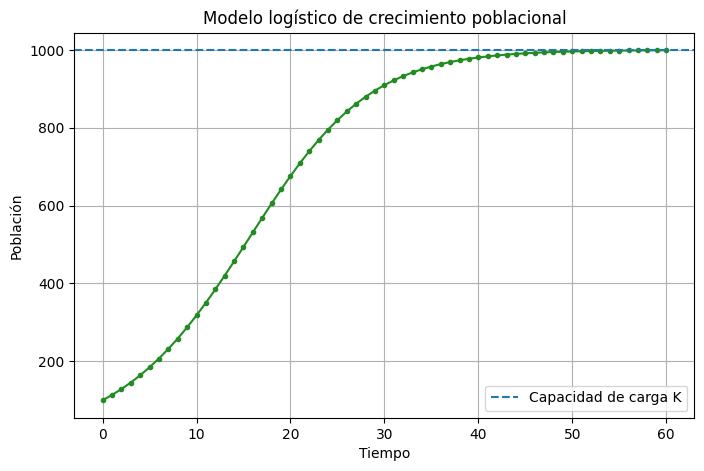

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(df["Tiempo"], df["Población"], marker="o", markersize=3, 
         color = 'forestgreen')
plt.axhline(y=K, linestyle="--", label="Capacidad de carga K")

plt.xlabel("Tiempo")
plt.ylabel("Población")
plt.title("Modelo logístico de crecimiento poblacional")
plt.legend()
plt.grid()

plt.show()

### Interpretación 

La curva tiene tres etapas principales:

**Primera etapa: crecimiento lento inicial**

Cuando la población es pequeña, el crecimiento comienza de forma moderada.

**Segunda etapa: crecimiento rápido**

Después de algunos periodos, la población aumenta con mayor rapidez porque hay suficientes individuos para reproducirse y todavía existen recursos disponibles.

**Tercera etapa: estabilización**

Cuando la población se acerca a la capacidad de carga $K$, el crecimiento se desacelera. Finalmente, la población se aproxima a $K = 1000.$ Esto significa que el ambiente ya no permite un crecimiento indefinido.

**Modelo exponencial discreto**

$$P_{t+1} = P_t + rP_t.$$

**Modelo logístico discreto**

$$P_{t+1} = P_t + rP_t \left( 1 - \frac{P_t}{K} \right).$$

El modelo exponencial no tiene límite superior, mientras que el modelo logístico incorpora una restricción mediante $K$.

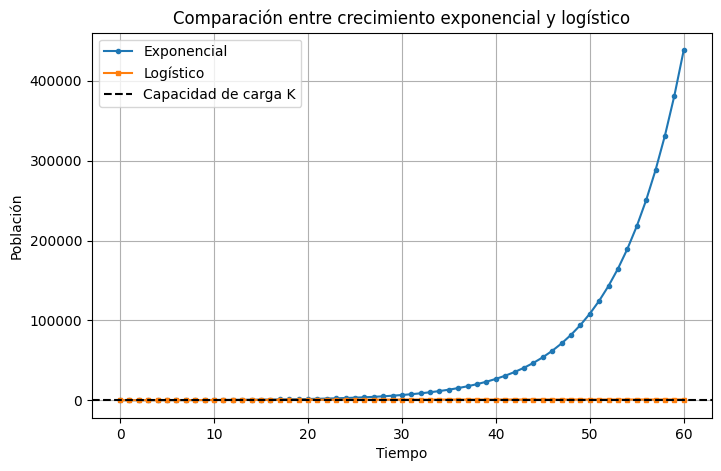

In [30]:
P0 = 100
r = 0.15
K = 1000
n = 60

tiempos = np.arange(0, n + 1)

# Simulación exponencial
P_exp = P0
poblacion_exp = []

for t in tiempos:
    poblacion_exp.append(P_exp)
    P_exp = P_exp + r * P_exp

# Simulación logística
P_log = P0
poblacion_log = []

for t in tiempos:
    poblacion_log.append(P_log)
    P_log = P_log + r * P_log * (1 - P_log / K)

# Gráfica comparativa
plt.figure(figsize=(8, 5))

plt.plot(tiempos, poblacion_exp, marker="o", markersize=3, 
         label="Exponencial")
plt.plot(tiempos, poblacion_log, marker="s", markersize=3, 
         label="Logístico")
plt.axhline(y=K, linestyle="--", label="Capacidad de carga K", 
            color='black')
#plt.xlim(0, 50)
plt.xlabel("Tiempo")
plt.ylabel("Población")
plt.title("Comparación entre crecimiento exponencial y logístico")
plt.legend()
plt.grid()

plt.show()

### Análisis de sensibilidad

Una parte importante de la modelación es estudiar qué ocurre cuando cambian los parámetros.

Por ejemplo, podemos modificar la tasa de crecimiento r.

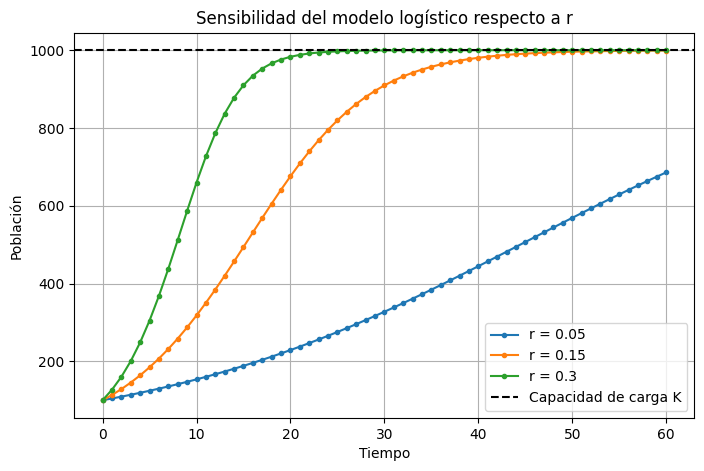

In [34]:
P0 = 100
K = 1000
n = 60

tasas = [0.05, 0.15, 0.30]
tiempos = np.arange(0, n + 1)

plt.figure(figsize=(8, 5))

for r in tasas:
    P = P0
    poblacion = []

    for t in tiempos:
        poblacion.append(P)
        P = P + r * P * (1 - P / K)

    plt.plot(tiempos, poblacion, marker="o", markersize=3, 
             label=f"r = {r}")

plt.axhline(y=K, linestyle="--", label="Capacidad de carga K", color = 'black')

plt.xlabel("Tiempo")
plt.ylabel("Población")
plt.title("Sensibilidad del modelo logístico respecto a r")
plt.legend()
plt.grid()

plt.show()

### Interpretación del análisis de sensibilidad

Si $r$ es pequeña, la población crece lentamente.

Si $r$ aumenta, la población alcanza más rápido la capacidad de carga.

Sin embargo, en todos los escenarios, la población tiende a estabilizarse cerca de $K$.

Esto muestra que el parámetro $r$ controla la rapidez del crecimiento, pero $K$ controla el nivel de estabilización.

El modelo logístico puede usarse para representar:

* crecimiento de poblaciones;
* propagación acumulada de usuarios de una tecnología;
* crecimiento de bacterias;
* adopción de una innovación;
* saturación de un mercado;
* evolución acumulada de casos en una epidemia en una fase controlada;
* crecimiento de ventas hasta alcanzar un límite de mercado.

En un **modelo determinista**, las condiciones iniciales y los parámetros determinan la evolución del sistema. Sin embargo, la utilidad del modelo depende de qué tan razonables sean sus supuestos y de qué tan bien interpretemos sus parámetros.

### Tarea 1. Modelo de crecimiento logístico aplicado a usuarios de una aplicación

Una aplicación nueva tiene inicialmente $P_0 = 250$ usuarios. Se estima que la cantidad máxima de usuarios que podría alcanzar en ese mercado es $K = 5000$. Supón que la tasa de crecimiento es $r = 0.12$ por semana.

El modelo logístico discreto es:

$$P_{t+1} = P_t + rP_t \left(1 - \frac{P_t}{K}\right).$$

#### Instrucciones

1. Simula el crecimiento durante 80 semanas.
2. Guarda los resultados en un `DataFrame` con las columnas:
   * `Semana`
   * `Usuarios`
3. Grafica la evolución de usuarios en el tiempo.
4. Agrega una línea horizontal que represente la capacidad máxima $K$.
5. Repite la simulación para tres valores de la tasa de crecimiento:

   $$r = 0.05, \quad r = 0.12, \quad r = 0.25.$$

6. Grafica los tres escenarios en una misma figura.
7. Responde en texto:
   * ¿Qué ocurre cuando aumenta $r$?
   * ¿La población de usuarios crece indefinidamente?
   * ¿Qué representa la capacidad de carga $K$ en este problema?

### Tarea 2. Modelo de depreciación de un automóvil

Un automóvil nuevo tiene un valor inicial de $V_0 = 320000$ pesos. Se estima que cada año pierde el $15\%$ de su valor respecto al año anterior.

Este fenómeno puede modelarse con:

$$V_{t+1} = V_t(1 - d),$$

donde:
* $V_t$ es el valor del automóvil en el año $t$,
* $d$ es la tasa de depreciación anual,
* $t$ representa el tiempo en años.



#### Instrucciones

1. Simula el valor del automóvil durante 15 años.
2. Guarda los resultados en un `DataFrame` con las columnas:
   * `Año`
   * `Valor del automóvil`
3. Grafica el valor del automóvil en función del tiempo.
4. Repite la simulación para tres tasas de depreciación:

   $$d = 0.10, \quad d = 0.15, \quad d = 0.25.$$

5. Grafica los tres escenarios en una misma figura.
6. Responde en texto:
   * ¿Qué representa el parámetro $d$?
   * ¿Qué ocurre con el valor del automóvil cuando aumenta $d$?
   * ¿El valor del automóvil llega exactamente a cero?
   * ¿Después de cuántos años el automóvil vale menos de la mitad de su valor inicial cuando $d = 0.15$?
   * ¿Qué limitaciones tiene este modelo en la vida real?